In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from lyapynov import ContinuousDS
from lyapynov import LCE


In [ ]:
# extremum seeking parameters
alpha = 0.1 #dither amplitude
omega_x = 15 #x dither frequency
omega_y = 23 #y dither frequency
omega_n = 1 #high pass filter cutoff frequency
k = 3  #learning rate

#cost function parameters
qx = 0.5
qy = 0.5
f_star = 1.0

#simulation parameters
t0 = 0.
dt = 1e-2

def rhs_auto(z, t):
            
            x, y, eta, mx, cx, my, cy = z

            J = f_star - qx*x**2 - qy*y**2 #quadratic cost function
            e = J - eta

            dx = k*e*mx + alpha*omega_x*cx
            dy = k*e*my + alpha*omega_y*cy
            deta = omega_n*e

            dmx = omega_x*cx
            dcx = -omega_x*mx
            dmy = omega_y*cy
            dcy = -omega_y*my

            return np.array([dx, dy, deta, dmx, dcx, dmy, dcy])

def jac_auto(z, t):
    x, y, eta, mx, cx, my, cy = z
    e = (f_star - qx*x**2 - qy*y**2) - eta
    
    # Initialize 7x7 zero matrix
    J_mat = np.zeros((7, 7))
    
    # Row 1: dx/d(states)
    J_mat[0, 0] = -2*k*qx*x*mx   # df1/dx
    J_mat[0, 1] = -2*k*qy*y*mx   # df1/dy
    J_mat[0, 2] = -k*mx          # df1/deta
    J_mat[0, 3] = k*e            # df1/dmx
    J_mat[0, 4] = alpha*omega_x  # df1/dcx
    
    # Row 2: dy/d(states)
    J_mat[1, 0] = -2*k*qx*x*my   # df2/dx
    J_mat[1, 1] = -2*k*qy*y*my   # df2/dy
    J_mat[1, 2] = -k*my          # df2/deta
    J_mat[1, 5] = k*e            # df2/dmy
    J_mat[1, 6] = alpha*omega_y  # df2/dcy
    
    # Row 3: deta/d(states)
    J_mat[2, 0] = -2*omega_n*qx*x # df3/dx
    J_mat[2, 1] = -2*omega_n*qy*y # df3/dy
    J_mat[2, 2] = -omega_n       # df3/deta
    
    # Rows 4-7: Oscillator dynamics (Linear)
    J_mat[3, 4] = omega_x        # dmx/dcx
    J_mat[4, 3] = -omega_x       # dcx/dmx
    J_mat[5, 6] = omega_y        # dmy/dcy
    J_mat[6, 5] = -omega_y       # dcy/dmy
    
    return J_mat

x0 = np.array([
    2, #x initial
    2, #y initial
    0, #eta
    np.sin(omega_x*t0),
    np.cos(omega_x*t0),
    np.sin(omega_y*t0),
    np.cos(omega_y*t0),
])
Lorenz63 = ContinuousDS(x0, t0, rhs_auto, jac_auto, dt)
Lorenz63.forward(10**6, False)

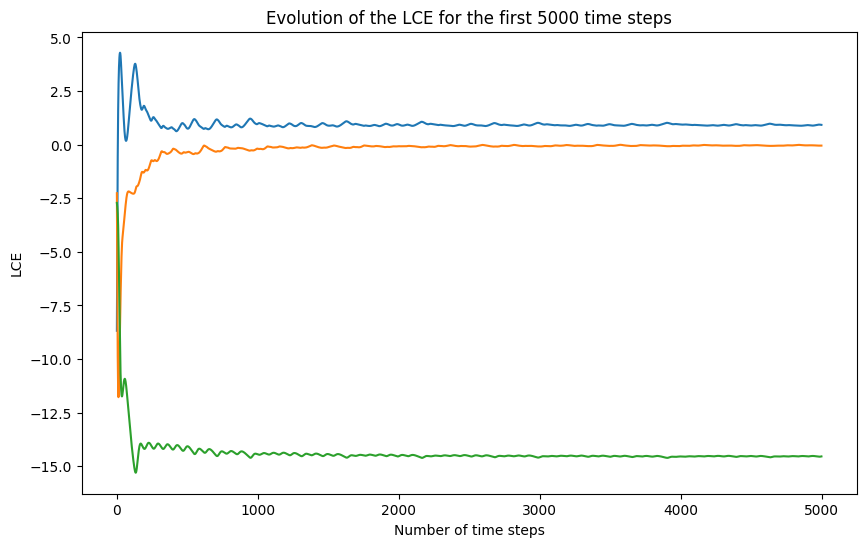

In [4]:
LCE, history = LCE(Lorenz63, 3, 0, 10**6, True)
plt.figure(figsize = (10,6))
plt.plot(history[:5000])
plt.xlabel("Number of time steps")
plt.ylabel("LCE")
plt.title("Evolution of the LCE for the first 5000 time steps")
plt.show()